# Ecommerce Purchase Prediction

The model predicts whether a session eventually purchases using only pre purchase behavior.

### Data Inspection

I started by inspecting the raw dataset to understand the structure of the ecommerce event data before cleaning or modeling.

This step helps determine the correct modeling approach. Because the data is event level, it cannot be used directly as one row per prediction. The project goal is to predict whether a session results in a purchase, so the raw events will need to be transformed into a session level table later.

I also reviewed summary statistics and data types to identify early data quality issues. The numeric summary is mainly useful for checking the price distribution. The data type inspection also shows that `event_time` needs to be converted into a datetime field before creating time based features.



In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
events = pd.read_csv('events.csv')

In [92]:
events.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [93]:
events.describe()

,product_id,category_id,price,user_id
count,8.851290e+05,8.851290e+05,885129.000000,8.851290e+05
mean,1.906621e+06,2.144423e+18,146.328713,1.515916e+18
std,1.458708e+06,6.165105e+14,296.807683,3.747287e+07
min,1.020000e+02,2.144416e+18,0.220000,1.515916e+18
25%,6.988030e+05,2.144416e+18,26.460000,1.515916e+18
50%,1.452883e+06,2.144416e+18,65.710000,1.515916e+18
75%,3.721194e+06,2.144416e+18,190.490000,1.515916e+18
max,4.183880e+06,2.227847e+18,64771.060000,1.515916e+18


In [94]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  object 
 1   event_type     885129 non-null  object 
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  object 
 5   brand          672765 non-null  object 
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 60.8+ MB


In [95]:
events.isnull().sum()

,0
event_time,0
event_type,0
product_id,0
category_id,0
category_code,236219
brand,212364
price,0
user_id,0
user_session,165


In [96]:
pd.Series({
    "users": events["user_id"].nunique(),
    "sessions": events["user_session"].nunique(),
    "products": events["product_id"].nunique(),
    "category_ids": events["category_id"].nunique(),
    "category_codes": events["category_code"].nunique(),
    "brands": events["brand"].nunique(),})

,0
users,407283
sessions,490398
products,53453
category_ids,718
category_codes,107
brands,999


### Data Cleaning

I cleaned the raw event data before building session level features. Exact duplicate rows were removed to avoid double counting user behavior. I also checked missing values and only dropped rows missing critical modeling fields such as `event_time`, `event_type`, `product_id`, `price`, `user_id`, and `user_session`.

I converted `event_time` into a datetime field so time based features like session duration, session hour, and day of week could be created later. I also removed invalid price values by keeping only rows with non-negative prices.


In [97]:
clean_events = events.copy()

# Drop exact duplicate rows
before = len(clean_events)
clean_events = clean_events.drop_duplicates()
print(f"Dropped {before - len(clean_events):,} duplicate rows")

# Drop rows missing fields required for session-level modeling
critical_cols = ["event_time", "event_type", "product_id", "price", "user_id", "user_session"]
clean_events = clean_events.dropna(subset=critical_cols)

# Convert timestamp
clean_events["event_time"] = pd.to_datetime(clean_events["event_time"], errors="coerce")
clean_events = clean_events.dropna(subset=["event_time"])

# Remove invalid prices if any exist
clean_events = clean_events[clean_events["price"] >= 0]

print("Cleaned shape:", clean_events.shape)
clean_events.head()

Dropped 655 duplicate rows
Cleaned shape: (884312, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [98]:
clean_events["event_type"].value_counts()

,count
event_type,
view,792943
cart,54026
purchase,37343


In [99]:
session_purchase_rate = (
    clean_events.groupby("user_session")["event_type"]
    .apply(lambda x: (x == "purchase").any())
    .mean())

session_purchase_rate

np.float64(0.04964131175086359)

### Session Level Feature Engineering

I converted the raw event level data into a session level modeling table, with one row per `user_session`. This is necessary because the prediction target is whether a session eventually results in a purchase.

To reduce target leakage, features were created only from behavior before the first purchase event. For non purchasing sessions, all view and cart events were kept. For purchasing sessions, only pre-purchase view and cart activity was used.

The final features capture session engagement and purchase intent, including event counts, views, carts, unique products, unique categories, price statistics, session duration, and cart/view ratios. The target variable, `purchased`, equals 1 if the session eventually had a purchase and 0 otherwise.

In [100]:
# First purchase time per session
first_purchase_time = (
    clean_events[clean_events["event_type"] == "purchase"]
    .groupby("user_session")["event_time"]
    .min()
    .reset_index()
    .rename(columns={"event_time": "first_purchase_time"}))

first_purchase_time.head()

,user_session,first_purchase_time
0,005wDfXQrv,2020-11-06 04:40:50+00:00
1,00IohNoWif,2021-02-20 09:06:30+00:00
2,00Mn72iK5R,2021-01-19 04:04:12+00:00
3,00RLUrffvt,2020-11-10 19:03:56+00:00
4,00p2pT8yws,2021-02-11 09:33:39+00:00


In [101]:
# Add first purchase time to every event
model_events = clean_events.merge(
    first_purchase_time,
    on="user_session",
    how="left")

model_events.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,first_purchase_time
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT,NaT
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,NaT
2,2020-09-24 11:57:27+00:00,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy,NaT
3,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,NaT
4,2020-09-24 11:57:36+00:00,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ,NaT


In [102]:
# Keep only behavior before the first purchase.
# If a session never purchased, keep all events.
feature_events = model_events[
    (model_events["first_purchase_time"].isna()) |
    (model_events["event_time"] < model_events["first_purchase_time"])].copy()

# The model should only see pre purchase browsing/cart behavior.
feature_events = feature_events[feature_events["event_type"].isin(["view", "cart"])]

feature_events["event_type"].value_counts()

,count
event_type,
view,765510
cart,50270


In [103]:
# Target from cleaned data
session_target = (
    clean_events.groupby("user_session")["event_type"]
    .apply(lambda x: (x == "purchase").any())
    .astype(int)
    .reset_index()
    .rename(columns={"event_type": "purchased"}))

session_target["purchased"].value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,95.04
1,4.96


In [104]:
# Build one row per session from pre-purchase feature events
session_features = feature_events.groupby("user_session").agg(
    user_id=("user_id", "first"),
    session_start=("event_time", "min"),
    session_end=("event_time", "max"),
    total_events=("event_type", "count"),
    unique_products=("product_id", "nunique"),
    unique_categories=("category_code", "nunique"),
    avg_price=("price", "mean"),
    max_price=("price", "max"),
    min_price=("price", "min")).reset_index()

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price
0,000AMhYaQu,1515915625599214495,2021-01-31 20:27:14+00:00,2021-01-31 20:27:14+00:00,1,1,0,12.06,12.06,12.06
1,000c34fa-991f-442a-8e07-8c472269bec6,1515915625509232600,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22
2,001HttdHUk,1515915625591270059,2021-01-09 23:35:49+00:00,2021-01-09 23:35:49+00:00,1,1,1,61.98,61.98,61.98
3,001P7lK0Pt,1515915625536141302,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,2,2,1,83.85,148.84,18.86
4,001RxUtFJa,1515915625570256322,2020-12-29 04:50:33+00:00,2020-12-29 04:50:33+00:00,1,1,1,104.21,104.21,104.21


In [105]:
# Add view/cart counts
view_cart_counts = (
    feature_events
    .pivot_table(
        index="user_session",
        columns="event_type",
        values="product_id",
        aggfunc="count",
        fill_value=0)
    .reset_index())

session_features = session_features.merge(
    view_cart_counts,
    on="user_session",
    how="left")

for col in ["view", "cart"]:
    if col not in session_features.columns:
        session_features[col] = 0

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price,cart,view
0,000AMhYaQu,1515915625599214495,2021-01-31 20:27:14+00:00,2021-01-31 20:27:14+00:00,1,1,0,12.06,12.06,12.06,0,1
1,000c34fa-991f-442a-8e07-8c472269bec6,1515915625509232600,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22,0,1
2,001HttdHUk,1515915625591270059,2021-01-09 23:35:49+00:00,2021-01-09 23:35:49+00:00,1,1,1,61.98,61.98,61.98,0,1
3,001P7lK0Pt,1515915625536141302,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,2,2,1,83.85,148.84,18.86,0,2
4,001RxUtFJa,1515915625570256322,2020-12-29 04:50:33+00:00,2020-12-29 04:50:33+00:00,1,1,1,104.21,104.21,104.21,0,1


In [106]:
# Merge the target onto the feature table
session_features = session_features.merge(
    session_target,
    on="user_session",
    how="left")

session_features["purchased"].value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,95.52
1,4.48


In [107]:
# Add simple behavioral/time features
session_features["session_duration_seconds"] = (
    session_features["session_end"] - session_features["session_start"]
).dt.total_seconds()

session_features["cart_rate"] = session_features["cart"] / session_features["total_events"]
session_features["view_rate"] = session_features["view"] / session_features["total_events"]
session_features["cart_to_view_ratio"] = session_features["cart"] / session_features["view"].replace(0, 1)

session_features["session_hour"] = session_features["session_start"].dt.hour
session_features["session_dayofweek"] = session_features["session_start"].dt.dayofweek
session_features["is_weekend"] = session_features["session_dayofweek"].isin([5, 6]).astype(int)

session_features.head()

,user_session,user_id,session_start,session_end,total_events,unique_products,unique_categories,avg_price,max_price,min_price,cart,view,purchased,session_duration_seconds,cart_rate,view_rate,cart_to_view_ratio,session_hour,session_dayofweek,is_weekend
0,000AMhYaQu,1515915625599214495,2021-01-31 20:27:14+00:00,2021-01-31 20:27:14+00:00,1,1,0,12.06,12.06,12.06,0,1,0,0.0,0.0,1.0,0.0,20,6,1
1,000c34fa-991f-442a-8e07-8c472269bec6,1515915625509232600,2020-09-30 17:52:02+00:00,2020-09-30 17:52:02+00:00,1,1,1,421.22,421.22,421.22,0,1,0,0.0,0.0,1.0,0.0,17,2,0
2,001HttdHUk,1515915625591270059,2021-01-09 23:35:49+00:00,2021-01-09 23:35:49+00:00,1,1,1,61.98,61.98,61.98,0,1,0,0.0,0.0,1.0,0.0,23,5,1
3,001P7lK0Pt,1515915625536141302,2020-11-06 01:25:30+00:00,2020-11-06 01:25:43+00:00,2,2,1,83.85,148.84,18.86,0,2,0,13.0,0.0,1.0,0.0,1,4,0
4,001RxUtFJa,1515915625570256322,2020-12-29 04:50:33+00:00,2020-12-29 04:50:33+00:00,1,1,1,104.21,104.21,104.21,0,1,0,0.0,0.0,1.0,0.0,4,1,0


### Quick EDA on the Final Modeling Table

I reviewed the final session level modeling table to confirm that the engineered features were created correctly before modeling. The table contains one row per session, with engagement features, cart and view ratios, time based features, and the binary target variable `purchased`.

I checked the data types and missing values to make sure the modeling columns were usable for machine learning. I then compared average session behavior between purchasing and non purchasing sessions.

Purchasing sessions showed higher engagement, with more total events, more views, more cart activity, more unique products, and longer session durations. Cart related features were the strongest signal, while average price was only slightly different between purchasing and non purchasing sessions.

In [108]:
session_features.info()
session_features.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487911 entries, 0 to 487910
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype              
---  ------                    --------------   -----              
 0   user_session              487911 non-null  object             
 1   user_id                   487911 non-null  int64              
 2   session_start             487911 non-null  datetime64[ns, UTC]
 3   session_end               487911 non-null  datetime64[ns, UTC]
 4   total_events              487911 non-null  int64              
 5   unique_products           487911 non-null  int64              
 6   unique_categories         487911 non-null  int64              
 7   avg_price                 487911 non-null  float64            
 8   max_price                 487911 non-null  float64            
 9   min_price                 487911 non-null  float64            
 10  cart                      487911 non-null  int64              
 11  

,0
user_session,0
user_id,0
session_start,0
session_end,0
total_events,0
unique_products,0
unique_categories,0
avg_price,0
max_price,0
min_price,0


In [109]:
session_features.groupby("purchased")[[
    "total_events",
    "view",
    "cart",
    "unique_products",
    "unique_categories",
    "avg_price",
    "session_duration_seconds",
    "cart_rate",
    "cart_to_view_ratio"
]].mean().T

purchased,0,1
total_events,1.581720,3.596697
view,1.527375,2.455552
cart,0.054346,1.141145
unique_products,1.259509,1.699181
unique_categories,0.717960,0.862241
avg_price,135.143665,140.022042
session_duration_seconds,22650.927762,31173.980921
cart_rate,0.015753,0.381628
cart_to_view_ratio,0.027437,0.701881


### Machine Learning

I used logistic regression as the baseline model because the target is binary: whether a session resulted in a purchase or not. Logistic regression is interpretable, outputs purchase probabilities, and provides a clear benchmark before trying more complex models.

Because purchase sessions are much less common than non purchase sessions, I used balanced class weights and evaluated the model with precision, recall, F1-score, ROC-AUC, and a confusion matrix instead of relying on accuracy alone.

In [110]:
feature_cols = [
    "total_events",
    "view",
    "cart",
    "unique_products",
    "unique_categories",
    "avg_price",
    "max_price",
    "min_price",
    "session_duration_seconds",
    "cart_rate",
    "view_rate",
    "cart_to_view_ratio",
    "session_hour",
    "session_dayofweek",
    "is_weekend"]

X = session_features[feature_cols].fillna(0)
y = session_features["purchased"]

X.head()

,total_events,view,cart,unique_products,unique_categories,avg_price,max_price,min_price,session_duration_seconds,cart_rate,view_rate,cart_to_view_ratio,session_hour,session_dayofweek,is_weekend
0,1,1,0,1,0,12.06,12.06,12.06,0.0,0.0,1.0,0.0,20,6,1
1,1,1,0,1,1,421.22,421.22,421.22,0.0,0.0,1.0,0.0,17,2,0
2,1,1,0,1,1,61.98,61.98,61.98,0.0,0.0,1.0,0.0,23,5,1
3,2,2,0,2,1,83.85,148.84,18.86,13.0,0.0,1.0,0.0,1,4,0
4,1,1,0,1,1,104.21,104.21,104.21,0.0,0.0,1.0,0.0,4,1,0


In [111]:
y.value_counts(normalize=True).round(4) * 100

,proportion
purchased,
0,95.52
1,4.48


In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42))])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [114]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = log_model.predict(X_test)
y_proba = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97     93212
           1       0.49      0.94      0.64      4371

    accuracy                           0.95     97583
   macro avg       0.74      0.95      0.81     97583
weighted avg       0.97      0.95      0.96     97583

ROC-AUC: 0.9599633791504208
[[88882  4330]
 [  254  4117]]


### Model Results and Business Interpretation

The purchase rate chart shows a sharp difference between sessions with and without cart activity. Sessions without cart activity had almost no purchases, while sessions with at least one cart event converted at about 50%.

The confusion matrix shows that the model captured most purchasing sessions, with 4,117 true positives and only 254 false negatives. The model also flagged some non purchasing sessions as likely purchasers, but this tradeoff could be acceptable for low cost marketing actions like remarketing, abandoned cart campaigns, or personalized checkout nudges.

In [115]:
session_features.groupby("purchased")[[
    "total_events",
    "view",
    "cart",
    "unique_products",
    "avg_price",
    "session_duration_seconds",
    "cart_rate",
    "cart_to_view_ratio"]].mean().T

purchased,0,1
total_events,1.581720,3.596697
view,1.527375,2.455552
cart,0.054346,1.141145
unique_products,1.259509,1.699181
avg_price,135.143665,140.022042
session_duration_seconds,22650.927762,31173.980921
cart_rate,0.015753,0.381628
cart_to_view_ratio,0.027437,0.701881


In [116]:
pd.crosstab(
    session_features["cart"] > 0,
    session_features["purchased"],
    normalize="index")

purchased,0,1
cart,,
False,0.997026,0.002974
True,0.499756,0.500244


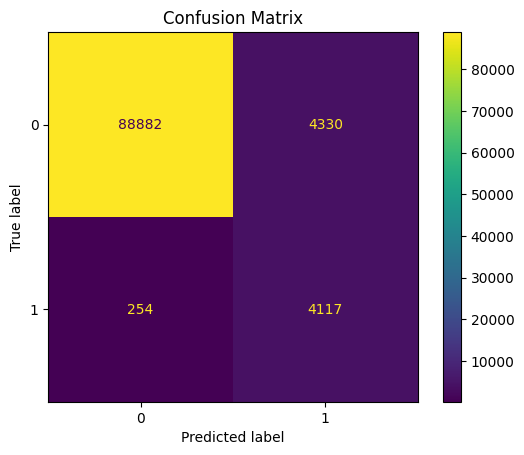

In [117]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

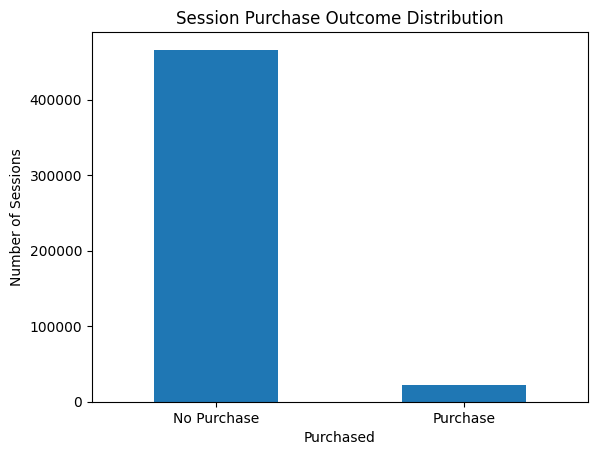

In [118]:


session_features["purchased"].value_counts().sort_index().plot(kind="bar")

plt.title("Session Purchase Outcome Distribution")
plt.xlabel("Purchased")
plt.ylabel("Number of Sessions")
plt.xticks([0, 1], ["No Purchase", "Purchase"], rotation=0)
plt.show()

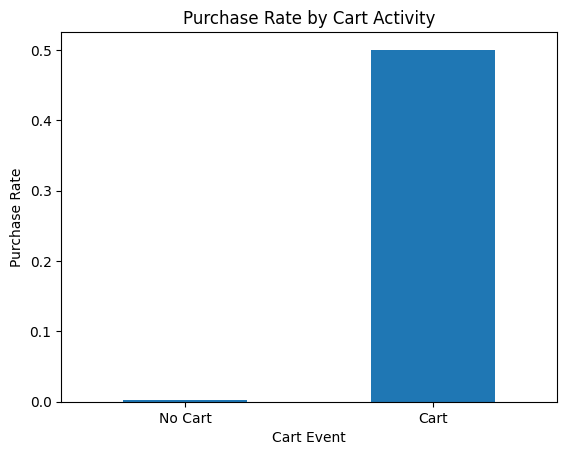

In [119]:
cart_purchase_rate = (
    session_features
    .assign(has_cart=session_features["cart"] > 0)
    .groupby("has_cart")["purchased"]
    .mean())

cart_purchase_rate.plot(kind="bar")

plt.title("Purchase Rate by Cart Activity")
plt.xlabel("Cart Event")
plt.ylabel("Purchase Rate")
plt.xticks([0, 1], ["No Cart", "Cart"], rotation=0)
plt.show()

### Conclusion

- Purchase intent became much clearer once users reached deeper funnel actions. Sessions with cart activity converted at about 50%, while sessions without cart activity rarely purchased.

- Purchasing sessions showed stronger engagement before conversion. They had more total events, more views, more cart actions, more unique products viewed, and longer session durations than non purchasing sessions.

- Cart intensity mattered more than raw activity volume. Purchasers had much higher cart rates and cart to view ratios, suggesting that the share of actions moving toward checkout was more predictive than total activity alone.

- Price was not a major separator between purchasing and non purchasing sessions. Average viewed price was only slightly higher for purchasing sessions, so behavioral signals were more useful than price alone.

- The model is best interpreted as a late stage purchase intent scoring tool. It can help identify sessions that are already showing strong buying intent for remarketing, abandoned cart campaigns, checkout nudges, or personalized offers.